<a href="https://colab.research.google.com/github/LuizaRamos/TOL506M_Final_Project/blob/main/notebooks/00_data_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TÖL506M - Introduction to Deep Neural Network
## Final Project: Wildlife Image Classification
### Data Exploration
**name:** Luiza V Sampaio Ramos, **email:** lvs2@gmail.com

This notebook uses the previous knolewged obtained from in the notebook: [pre data exploration notebook](https://colab.research.google.com/drive/1RCoya0Jx7hhm9RKAMVe49zl6Z6MwfdFg?usp=sharing), which doesn't use any connection to the project.

In the present notebook, the dataset is loaded and has its labels translated to English, from the original Italian labels. The distribution between labels is analysed, for the full dataset, but also for data split (training, validation , and testing), given each data fraction (10%, 25%, 50%, 75%, and 100%) of the training data.

**Observation:** The first cell of code bellow was implemente to be able to run the notebook using Google Colab, while the rest o the code was initially wroten using DataSpell.

In [1]:
# 1) Configure your repo details
REPO_URL = "https://github.com/LuizaRamos/TOL506M_Final_Project.git"
REPO_DIR = "/content/TOL506M_Final_Project"

# 2) Clone or update the repo
import os, sys, subprocess, pathlib

if not os.path.exists(REPO_DIR):
    subprocess.run(["git", "clone", REPO_URL, REPO_DIR], check=True)
else:
    # pull latest; safe if you want current main
    subprocess.run(["git", "-C", REPO_DIR, "pull", "--ff-only"], check=True)

# 3) Make the repo root the working directory
os.chdir(REPO_DIR)

# 4) Put the repo on PYTHONPATH so `from utils import ...` etc. works
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)
os.environ["PYTHONPATH"] = REPO_DIR + os.pathsep + os.environ.get("PYTHONPATH", "")

In [2]:
import sys
import os
import subprocess
import importlib
import numpy as np
from pathlib import Path
from collections import Counter
import random
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import torch
from torchvision import datasets, transforms

project_root = Path.cwd()
if project_root.name != "TOL506M_Final_Project":
    original = project_root
    while project_root.name != "TOL506M_Final_Project" and project_root != project_root.parent:
        project_root = project_root.parent

    if project_root.name == "TOL506M_Final_Project":
        os.chdir(project_root)
        print(f"Changed working directory from {original} to {project_root}")
    else:
        raise RuntimeError(
            "Could not locate the TOL506M_Final_Project root directory. "
            "Please run this notebook/script from within the project tree."
        )
else:
    print(f"Working directory: {project_root}")

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

Working directory: /content/TOL506M_Final_Project


In [3]:
# ---------------------------------------------------------------------------
# Import project modules
# ---------------------------------------------------------------------------
from data.dataset import (
    WildlifeDataset,
    stratified_split,
    get_data_loaders,
    is_italian,
    translate_names,
    get_class_names
)
from data.augmentation import get_train_transforms, get_val_transforms

In [4]:
# Plot styling
sns.set_style("whitegrid")
plt.rcParams.update({"figure.figsize": (12, 6), "font.size": 12})

print(f"\nPyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")


PyTorch version: 2.8.0+cu126
CUDA available: True


In [5]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("alessiocorrado99/animals10")

print(f'Dataset downloaded: {path}\n')

Using Colab cache for faster access to the 'animals10' dataset.
Dataset downloaded: /kaggle/input/animals10



In [6]:
DATA_PATH = Path(path) / 'raw-img'

basic_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

full_dataset = datasets.ImageFolder(root=str(DATA_PATH), transform=basic_transform)

print(f'Total images: {len(full_dataset)}\n')
print(f'Classes: {full_dataset.classes}\n')

Total images: 26179

Classes: ['cane', 'cavallo', 'elefante', 'farfalla', 'gallina', 'gatto', 'mucca', 'pecora', 'ragno', 'scoiattolo']



In [7]:
full_dataset

Dataset ImageFolder
    Number of datapoints: 26179
    Root location: /kaggle/input/animals10/raw-img
    StandardTransform
Transform: Compose(
               Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
           )

In [8]:
# Translating from Italian to English
dataset = translate_names(full_dataset)

class_names = get_class_names(full_dataset)
print(f'\n Class names: {class_names}')


 Class names: ['dog', 'horse', 'elephant', 'butterfly', 'chicken', 'cat', 'cow', 'sheep', 'spider', 'squirrel']


In [9]:
# Class Distribution Full Dataset
labels = [label for _, label in dataset.imgs]

class_counts = Counter(labels)
sorted_classes = sorted(class_counts.items(), key=lambda x: x[1], reverse=True)

print("\nSamples per class:")
for class_idx, count in sorted_classes:
    percentage = (count / len(labels)) * 100
    print(f"  {class_names[class_idx]:10s}: {count:5d} samples {percentage:.0f}%")


Samples per class:
  dog       :  4863 samples 19%
  spider    :  4821 samples 18%
  chicken   :  3098 samples 12%
  horse     :  2623 samples 10%
  butterfly :  2112 samples 8%
  cow       :  1866 samples 7%
  squirrel  :  1862 samples 7%
  sheep     :  1820 samples 7%
  cat       :  1668 samples 6%
  elephant  :  1446 samples 6%


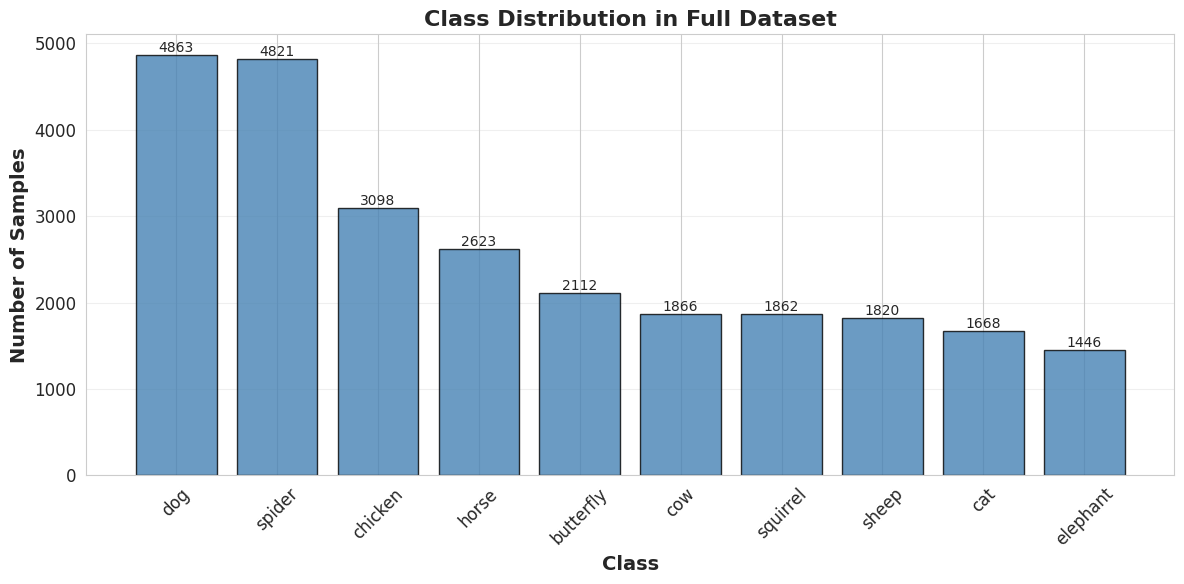

In [10]:
# Visualization of the Class Distribution
fig, ax = plt.subplots(figsize=(12, 6))
class_labels = [class_names[idx] for idx, _ in sorted_classes]
counts = [count for _, count in sorted_classes]

bars = ax.bar(class_labels, counts, color='steelblue', alpha=0.8, edgecolor='black')
ax.set_xlabel('Class', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Samples', fontsize=14, fontweight='bold')
ax.set_title('Class Distribution in Full Dataset', fontsize=16, fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3)

# Add count labels on bars
for bar, count in zip(bars, counts):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(count)}',
            ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

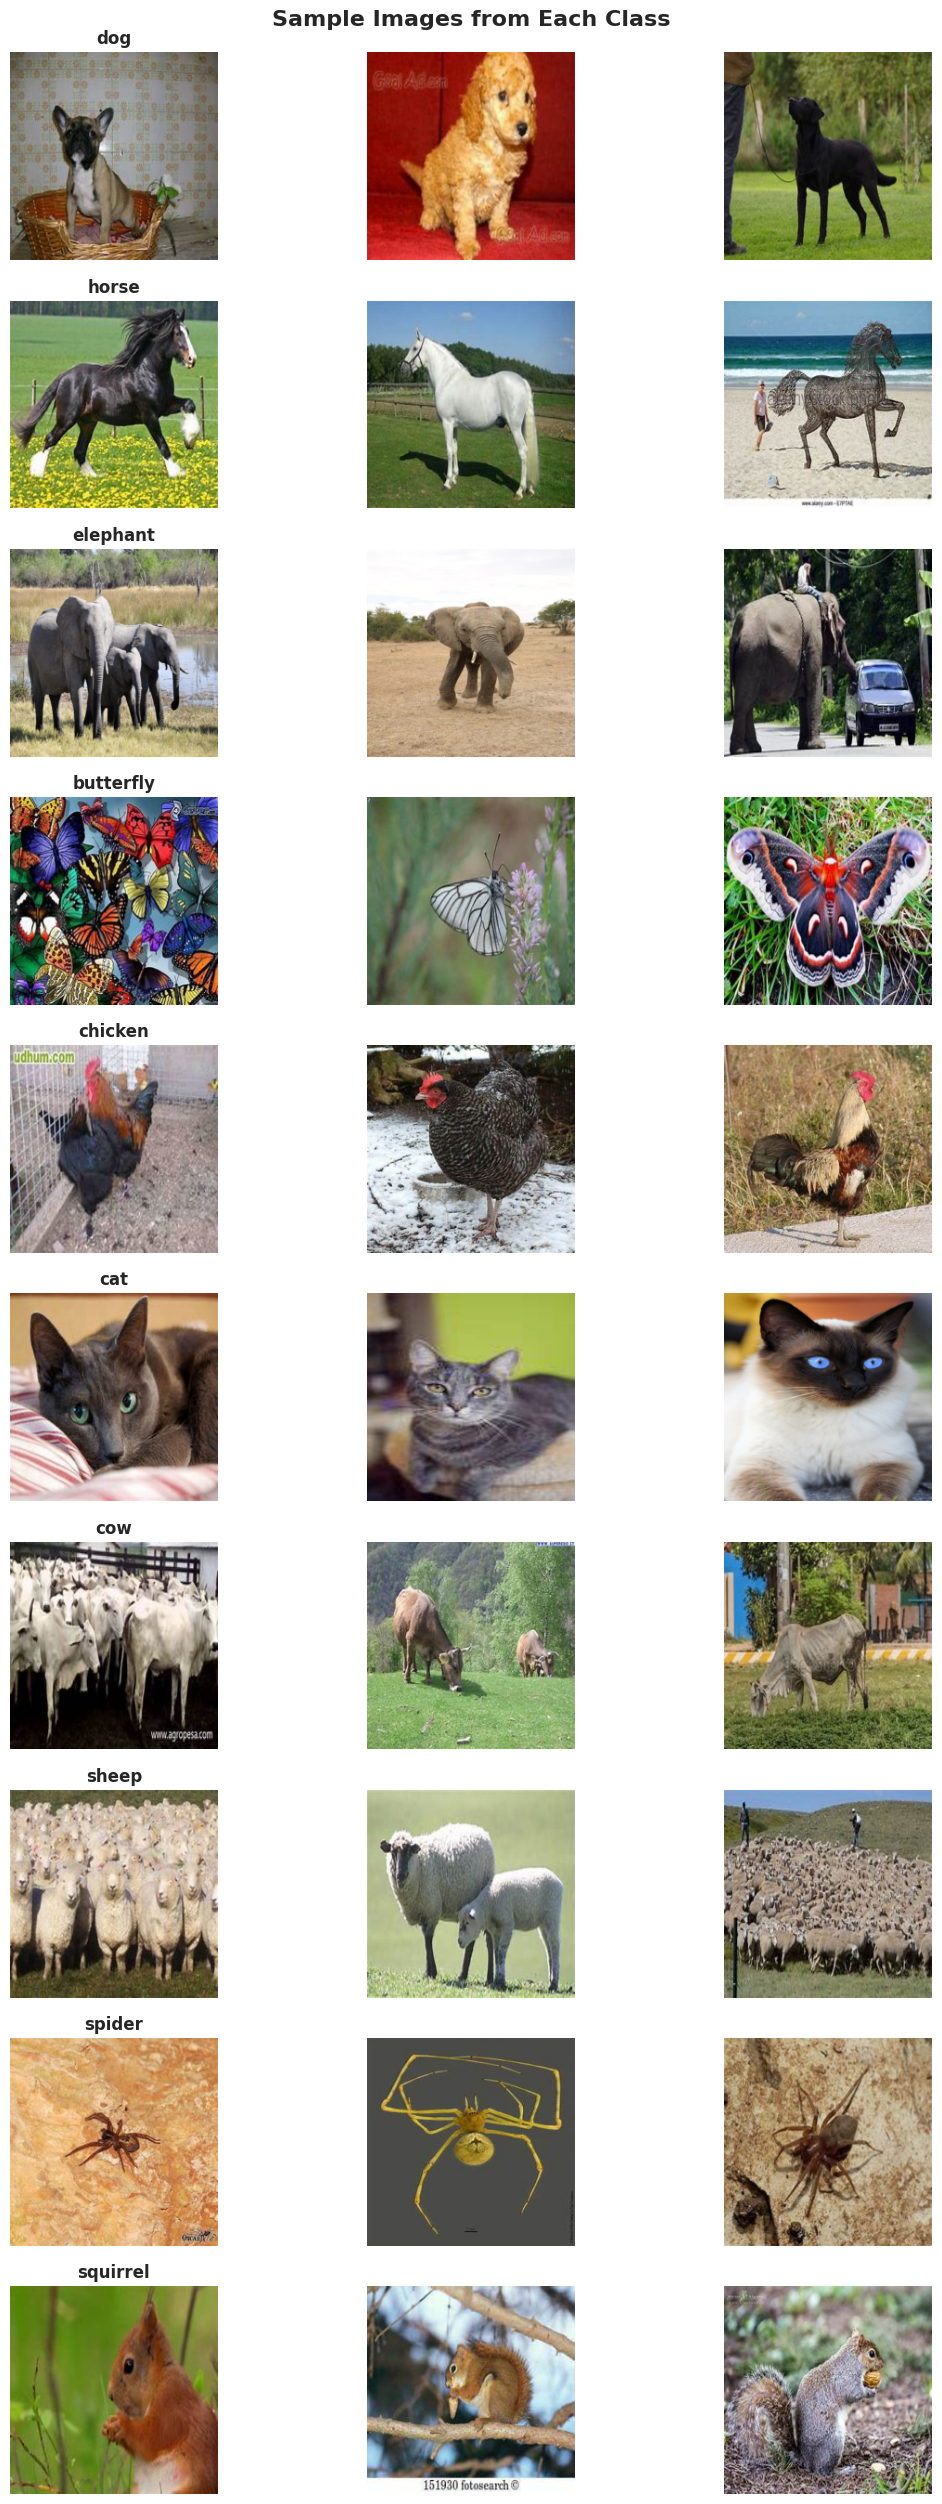

In [11]:
# Display sample images from each class
n_classes = len(class_names)
n_samples_per_class = 3

fig, axes = plt.subplots(n_classes, n_samples_per_class,
                          figsize=(12, n_classes * 2.5))

for class_idx, class_name in enumerate(class_names):
    # Find indices for this class
    class_indices = [i for i, label in enumerate(labels) if label == class_idx]

    # Sample random images
    sample_indices = np.random.choice(class_indices,
                                     min(n_samples_per_class, len(class_indices)),
                                     replace=False)

    for col, img_idx in enumerate(sample_indices):
        img, label = full_dataset[img_idx]

        # Convert tensor to numpy array for display
        img_np = img.permute(1, 2, 0).numpy()

        ax = axes[class_idx, col] if n_classes > 1 else axes[col]
        ax.imshow(img_np)
        ax.axis('off')

        if col == 0:
            ax.set_title(f'{class_name}', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.suptitle('Sample Images from Each Class', fontsize=16, fontweight='bold', y=1.001)
plt.show()

In [12]:
# Analysing the different data splits based on the data fraction
from config import Config

data_fractions = Config.DATA_FRACTION
train_split = Config.TRAIN_SPLIT
val_split = Config.VAL_SPLIT
test_split = Config.TEST_SPLIT
random_seed = Config.RANDOM_SEED

split_results = {}

for frac in data_fractions:
    print(f'\nData Fraction: {frac*100:.0f}%')

    # Create data
    train_loader, val_loader, test_loader, num_classes = get_data_loaders(
        data_path=str(DATA_PATH),
        batch_size=32,
        num_workers=0,  # Set to 0 for notebook compatibility
        train_split=train_split,
        val_split=val_split,
        test_split=test_split,
        use_augmentation=False,
        random_seed=random_seed,
        data_fraction=frac
    )

    # Calculate sizes
    train_size = len(train_loader.dataset)
    val_size = len(val_loader.dataset)
    test_size = len(test_loader.dataset)
    total_size = train_size + val_size + test_size

    print(f"  Training samples:   {train_size:5d} ({train_size/total_size*100:.1f}%)")
    print(f"  Validation samples: {val_size:5d} ({val_size/total_size*100:.1f}%)")
    print(f"  Test samples:       {test_size:5d} ({test_size/total_size*100:.1f}%)")
    print(f"  Total samples:      {total_size:5d}")

    # Store results
    split_results[frac] = {
        'train': train_size,
        'val': val_size,
        'test': test_size,
        'total': total_size
    }

    # Analyze class distribution in training set
    train_labels = []
    for _, labels in train_loader:
        train_labels.extend(labels.numpy())

    train_class_counts = Counter(train_labels)

    print(f"\n  Training set class distribution:")
    for class_idx in range(num_classes):
        count = train_class_counts.get(class_idx, 0)
        percent = (count / train_size) * 100
        print(f"    {class_names[class_idx]:15s}: {count:4d} samples ({percent:.0f}%)")


Data Fraction: 10%
  Training samples:    1832 (18.9%)
  Validation samples:  3927 (40.5%)
  Test samples:        3927 (40.5%)
  Total samples:       9686

  Training set class distribution:
    dog            :  340 samples (19%)
    horse          :  184 samples (10%)
    elephant       :  101 samples (6%)
    butterfly      :  148 samples (8%)
    chicken        :  217 samples (12%)
    cat            :  117 samples (6%)
    cow            :  131 samples (7%)
    sheep          :  127 samples (7%)
    spider         :  337 samples (18%)
    squirrel       :  130 samples (7%)

Data Fraction: 25%
  Training samples:    4581 (36.8%)
  Validation samples:  3927 (31.6%)
  Test samples:        3927 (31.6%)
  Total samples:      12435

  Training set class distribution:
    dog            :  851 samples (19%)
    horse          :  459 samples (10%)
    elephant       :  253 samples (6%)
    butterfly      :  369 samples (8%)
    chicken        :  542 samples (12%)
    cat            :  29